In [1]:
from __future__ import annotations

import warnings

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from utilities import (
    compute_means,
    compute_medians,
    hundreds_of_thousands_formater,
    tens_of_thousands_formater,
)

warnings.simplefilter(action="ignore", category=FutureWarning)

sns.set_theme(context="paper")
sns.set_palette("gray")

In [2]:
df = pd.read_stata("../data/scf_processed.dta")

filtered_df = df[
    (df["racecl4_lbl"] != "Other or Multiple race")
    & df["age"].between(21, 80)
    & (df["networth"] > 0)
    & (df["asset"] > 0)
    & (df["fin"] > 0)
    & (df["income"])
    & (df["equityfin"]).between(0, 1)
]

In [3]:
grouped_means = filtered_df.groupby(["year", "race_lbl"]).apply(compute_means)

/tmp/ipykernel_1424117/3300519176.py:1: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  grouped_means = filtered_df.groupby(["year", "race_lbl"]).apply(compute_means)


/tmp/ipykernel_1424117/3201500694.py:42: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45)
/tmp/ipykernel_1424117/3201500694.py:42: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45)
/tmp/ipykernel_1424117/3201500694.py:42: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45)


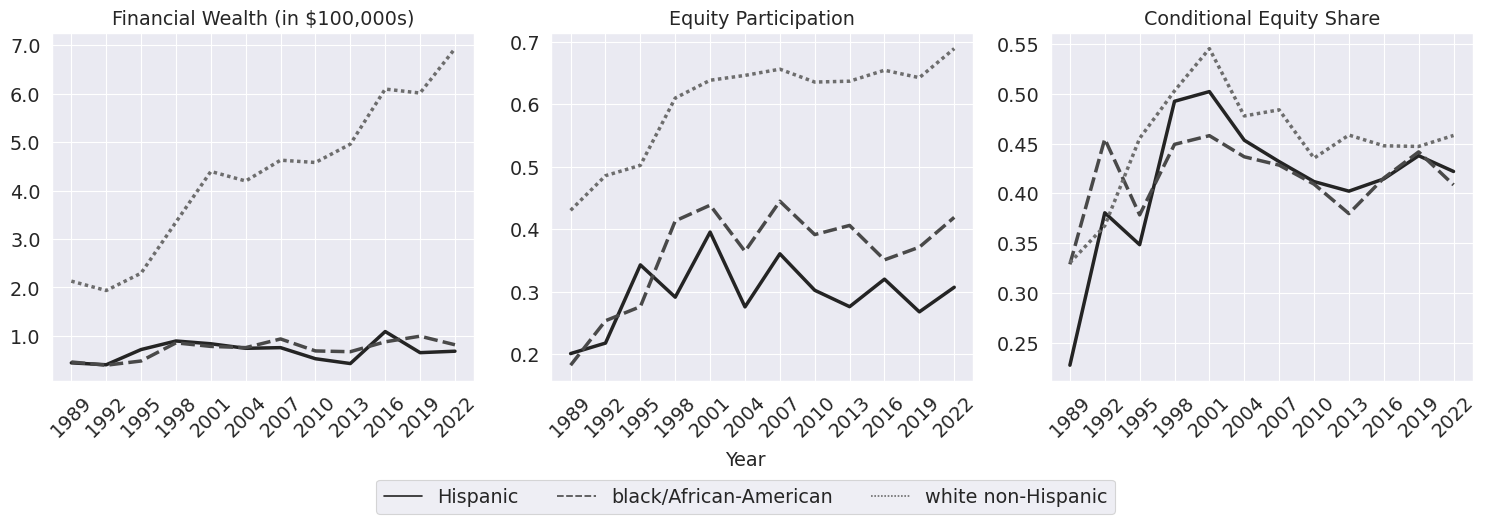

In [4]:
# Create a function to format y-axis values into hundreds of thousands


# Create a figure and a grid of subplots
fig, axs = plt.subplots(ncols=3, figsize=(15, 5))

# Define the metrics to be plotted
metrics = ["fin", "hequity", "equityfin"]
titles = [
    "Financial Wealth (in $100,000s)",
    "Equity Participation",
    "Conditional Equity Share",
]

# Loop through each metric and create a line graph
lines = []
labels = []
for i, metric in enumerate(metrics):
    ax = sns.lineplot(
        x="year",
        y=metric,
        hue="race_lbl",
        style="race_lbl",
        data=grouped_means,
        ax=axs[i],
        linewidth=2.5,
    )
    axs[i].set_title(titles[i], fontsize="x-large")

    # Format y-axis on the first figure in hundreds of thousands
    if i == 0:
        ax.yaxis.set_major_formatter(hundreds_of_thousands_formater)

    # Remove the legend for individual subplot
    ax.get_legend().remove()

    # Remove the x-label for individual subplot
    ax.set_xlabel("")
    ax.set_ylabel("")

    # Rotate x-labels by 45 degrees
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45)

    # Increase the size of x and y tick labels
    ax.tick_params(axis="both", which="major", labelsize="x-large")

    # Get the handles and labels for the first execution only
    if i == 0:
        lines, labels = ax.get_legend_handles_labels()

# Add a single legend to the figure below the subplots
# Move the legend closer to the figures by adjusting the bbox_to_anchor parameter
# Increase the fontsize to make the legend larger
fig.legend(
    lines,
    labels,
    loc="upper center",
    bbox_to_anchor=(0.5, 0),
    ncol=4,
    fontsize="x-large",
)

# Add a common x-label for all subplots
fig.text(0.5, 0.02, "Year", ha="center", va="center", fontsize="x-large")


# Display the plot with enough space for the legend
plt.tight_layout(rect=[0, 0.03, 1, 0.95])

plt.savefig("equity_year.svg", bbox_inches="tight")
plt.savefig("equity_year.pdf", bbox_inches="tight")

plt.show()

In [5]:
grouped_medians = filtered_df.groupby(["year", "race_lbl"]).apply(compute_medians)

/tmp/ipykernel_1424117/2837041392.py:1: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  grouped_medians = filtered_df.groupby(["year", "race_lbl"]).apply(compute_medians)


/tmp/ipykernel_1424117/732118475.py:42: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45)
/tmp/ipykernel_1424117/732118475.py:42: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45)
/tmp/ipykernel_1424117/732118475.py:42: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45)


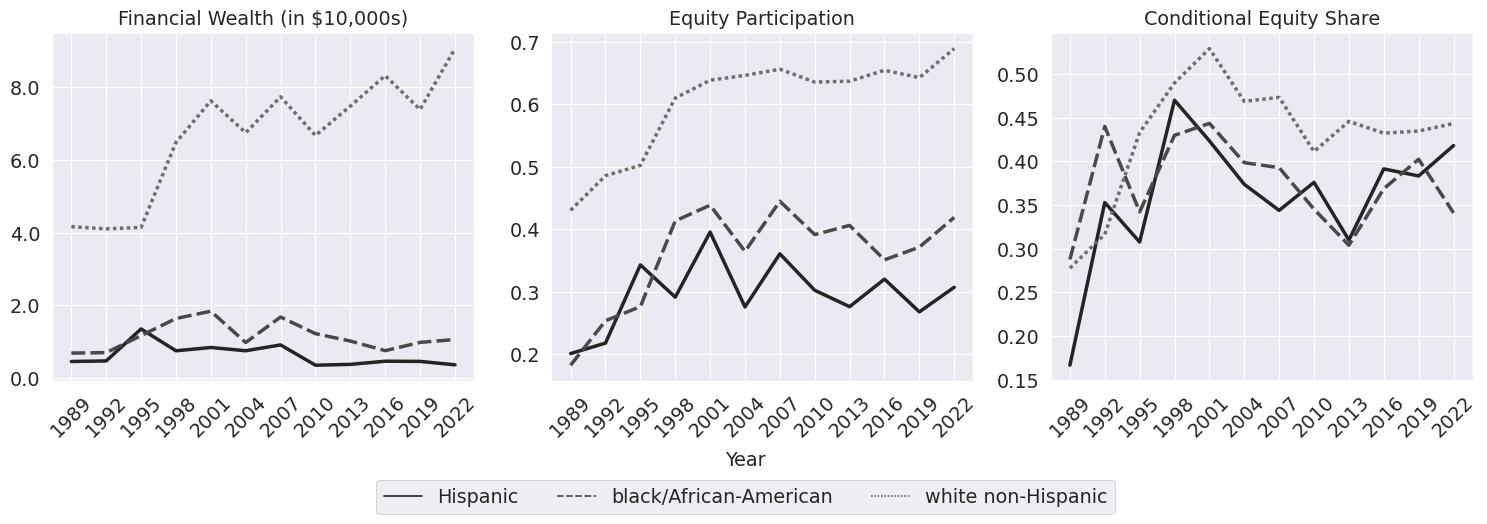

In [6]:
# Create a function to format y-axis values into hundreds of thousands


# Create a figure and a grid of subplots
fig, axs = plt.subplots(ncols=3, figsize=(15, 5))

# Define the metrics to be plotted
metrics = ["fin", "hequity", "equityfin"]
titles = [
    "Financial Wealth (in $10,000s)",
    "Equity Participation",
    "Conditional Equity Share",
]

# Loop through each metric and create a line graph
lines = []
labels = []
for i, metric in enumerate(metrics):
    ax = sns.lineplot(
        x="year",
        y=metric,
        hue="race_lbl",
        style="race_lbl",
        data=grouped_medians,
        ax=axs[i],
        linewidth=2.5,
    )
    axs[i].set_title(titles[i], fontsize="x-large")

    # Format y-axis on the first figure in hundreds of thousands
    if i == 0:
        ax.yaxis.set_major_formatter(tens_of_thousands_formater)

    # Remove the legend for individual subplot
    ax.get_legend().remove()

    # Remove the x-label for individual subplot
    ax.set_xlabel("")
    ax.set_ylabel("")

    # Rotate x-labels by 45 degrees
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45)

    # Increase the size of x and y tick labels
    ax.tick_params(axis="both", which="major", labelsize="x-large")

    # Get the handles and labels for the first execution only
    if i == 0:
        lines, labels = ax.get_legend_handles_labels()

# Add a single legend to the figure below the subplots
# Move the legend closer to the figures by adjusting the bbox_to_anchor parameter
# Increase the fontsize to make the legend larger
fig.legend(
    lines,
    labels,
    loc="upper center",
    bbox_to_anchor=(0.5, 0),
    ncol=4,
    fontsize="x-large",
)

# Add a common x-label for all subplots
fig.text(0.5, 0.02, "Year", ha="center", va="center", fontsize="x-large")


# Display the plot with enough space for the legend
plt.tight_layout(rect=[0, 0.03, 1, 0.95])

plt.savefig("equity_year.svg", bbox_inches="tight")
plt.savefig("equity_year.pdf", bbox_inches="tight")

plt.show()